In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
model = load_model("../models/bilstm_arabic_sentiment.keras")

with open("../models/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

with open("../models/label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

print("Classes :", le.classes_)
print("Model   : loaded ✓")

Classes : ['negative' 'neutral' 'positive']
Model   : loaded ✓


In [3]:
train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")

def encode(texts, tokenizer, max_len=50):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=max_len, padding="post", truncating="post")

X_test = encode(test["clean_text"], tokenizer)
y_test = le.transform(test["label"])

print(f"Test samples : {len(test):,}")
test.head(3)

Test samples : 14,722


,text,label,clean_text,word_count,char_count
0,معرض قمة البرج للسيارات الافضل لكم 💳🚘 #فايبر_S...,neutral,معرض قمه البرج للسيارات الافضل لكم,6,34
1,@mhrsd_care عندي سوال بالنسبه للامر الملكي هل ...,neutral,عندي سوال بالنسبه للامر الملكي هل يشمل شركات ا...,12,67
2,#لبنان_ينتفض #لبنان_يغرق #أموال_الشعب_اللبناني...,negative,اين ذهبت سؤال لبعض الوزراء الذي يدعم بعضهم ميل...,11,57


In [4]:
y_probs = model.predict(X_test, verbose=0)
y_pred  = np.argmax(y_probs, axis=1)

print("Sample predictions:\n")
for i in range(5):
    print(f"  text      : {test['text'].iloc[i][:80]}")
    print(f"  actual    : {le.inverse_transform([y_test[i]])[0]}")
    print(f"  predicted : {le.inverse_transform([y_pred[i]])[0]}")
    print(f"  confidence: {y_probs[i].max():.2%}\n")

Sample predictions:

  text      : معرض قمة البرج للسيارات الافضل لكم 💳🚘 #فايبر_STC_ب99ريال
  actual    : neutral
  predicted : positive
  confidence: 47.51%

  text      : @mhrsd_care عندي سوال بالنسبه للامر الملكي هل يشمل شركات القطاع الخاص للدوام ؟؟!
  actual    : neutral
  predicted : neutral
  confidence: 98.92%

  text      : #لبنان_ينتفض #لبنان_يغرق #أموال_الشعب_اللبناني أين ذهبت سؤال لبعض الوزراء الذي ي
  actual    : negative
  predicted : neutral
  confidence: 87.05%

  text      : اللهم أسعدنا في أبسط تفاصيل حياتنا وقرب لنا الخير حيث كان 💙
  actual    : positive
  predicted : neutral
  confidence: 58.02%

  text      : @SaudiHousingCC ايش يعني تحت الانشاء؟؟ فيما بعد استلمها جاهزه؟
  actual    : neutral
  predicted : neutral
  confidence: 55.34%



In [5]:
print("── BiLSTM Classification Report ──\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

── BiLSTM Classification Report ──

              precision    recall  f1-score   support

    negative       0.42      0.74      0.54      2327
     neutral       0.89      0.71      0.79     10105
    positive       0.53      0.60      0.56      2290

    accuracy                           0.69     14722
   macro avg       0.61      0.68      0.63     14722
weighted avg       0.76      0.69      0.71     14722



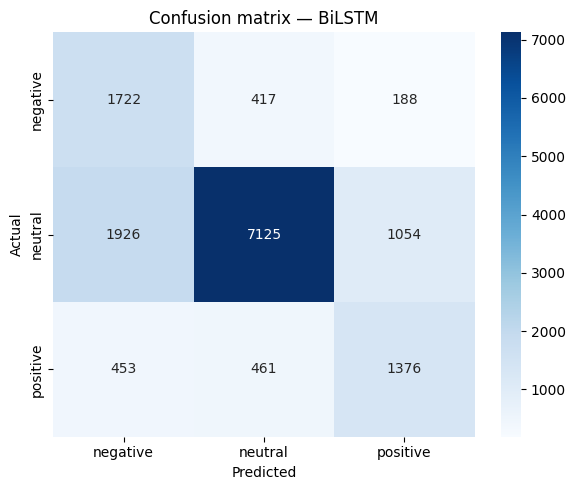

In [6]:
LABEL_COLORS = {"positive": "#1D9E75", "negative": "#D85A30", "neutral": "#888780"}

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion matrix — BiLSTM")
plt.tight_layout()
plt.savefig("../results/confusion_matrix.png", dpi=150)
plt.show()

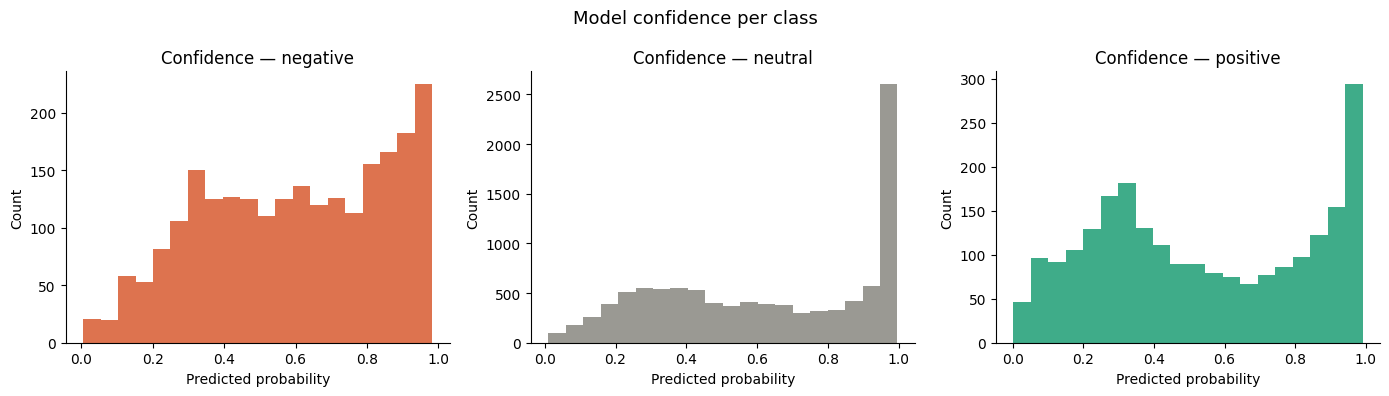

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, (ax, label) in enumerate(zip(axes, le.classes_)):
    mask = y_test == i
    ax.hist(y_probs[mask, i], bins=20,
            color=LABEL_COLORS[label], edgecolor='none', alpha=0.85)
    ax.set_title(f"Confidence — {label}")
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Count")
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle("Model confidence per class", fontsize=13)
plt.tight_layout()
plt.savefig("../results/confidence_dist.png", dpi=150)
plt.show()

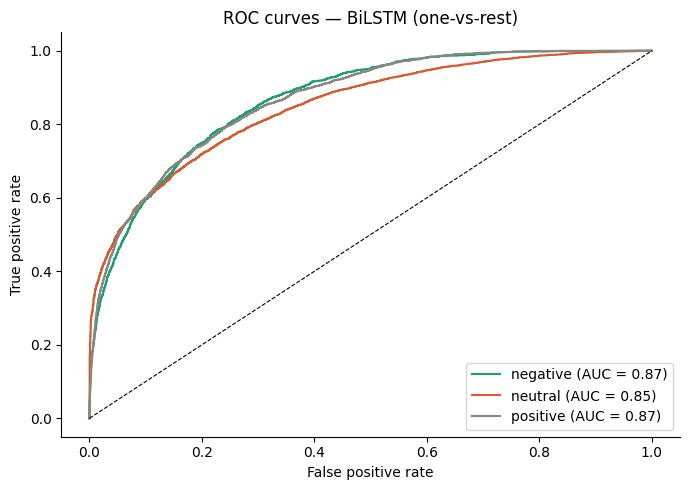

In [8]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, ax = plt.subplots(figsize=(7, 5))
for i, label in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.2f})",
            color=list(LABEL_COLORS.values())[i])

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves — BiLSTM (one-vs-rest)")
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("../results/roc_curves.png", dpi=150)
plt.show()

In [9]:
y_train = le.transform(train["label"])

tfidf = TfidfVectorizer(max_features=30_000, ngram_range=(1, 2))
X_tr_tfidf   = tfidf.fit_transform(train["clean_text"])
X_test_tfidf = tfidf.transform(test["clean_text"])

lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_tr_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

print("── TF-IDF + Logistic Regression Report ──\n")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

── TF-IDF + Logistic Regression Report ──

              precision    recall  f1-score   support

    negative       0.46      0.66      0.55      2327
     neutral       0.89      0.72      0.79     10105
    positive       0.48      0.66      0.56      2290

    accuracy                           0.70     14722
   macro avg       0.61      0.68      0.63     14722
weighted avg       0.76      0.70      0.72     14722



In [10]:
from sklearn.metrics import f1_score, accuracy_score

results = pd.DataFrame({
    "Model": ["TF-IDF + LR (baseline)", "BiLSTM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred)
    ],
    "F1 macro": [
        f1_score(y_test, y_pred_lr, average="macro"),
        f1_score(y_test, y_pred,    average="macro")
    ],
    "F1 weighted": [
        f1_score(y_test, y_pred_lr, average="weighted"),
        f1_score(y_test, y_pred,    average="weighted")
    ],
}).round(4)

results.to_csv("../results/model_comparison.csv", index=False)
print(results.to_string(index=False))

                 Model  Accuracy  F1 macro  F1 weighted
TF-IDF + LR (baseline)    0.7025    0.6326       0.7180
                BiLSTM    0.6944    0.6278       0.7121


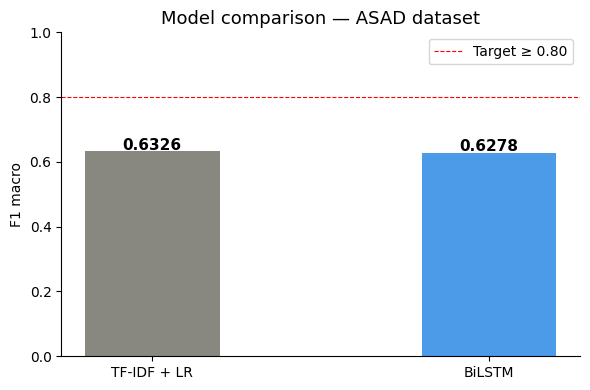

In [11]:
models    = ["TF-IDF + LR", "BiLSTM"]
f1_scores = [
    f1_score(y_test, y_pred_lr, average="macro"),
    f1_score(y_test, y_pred,    average="macro")
]
colors = ["#888780", "#4C9BE8"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(models, f1_scores, color=colors, width=0.4, edgecolor='none')
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{score:.4f}", ha='center', fontsize=11, fontweight='bold')

ax.set_ylim(0, 1.0)
ax.set_ylabel("F1 macro")
ax.set_title("Model comparison — ASAD dataset", fontsize=13)
ax.axhline(0.80, color='red', linestyle='--', linewidth=0.8, label="Target ≥ 0.80")
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("../results/model_comparison_chart.png", dpi=150)
plt.show()

In [12]:
test_copy = test.copy()
test_copy["actual"]     = le.inverse_transform(y_test)
test_copy["predicted"]  = le.inverse_transform(y_pred)
test_copy["confidence"] = y_probs.max(axis=1).round(4)
test_copy["correct"]    = test_copy["actual"] == test_copy["predicted"]

errors = test_copy[~test_copy["correct"]].sort_values("confidence", ascending=False)

print(f"Total errors : {len(errors):,} / {len(test_copy):,}")
print(f"Error rate   : {len(errors)/len(test_copy):.2%}\n")
print("── High-confidence mistakes ──")
errors[["text", "actual", "predicted", "confidence"]].head(10)

Total errors : 4,499 / 14,722
Error rate   : 30.56%

── High-confidence mistakes ──


,text,actual,predicted,confidence
1006,@sakani_housing السلام عليكم هل الموظفه يحق له...,positive,neutral,0.9932
12171,@eMoroor لدي قرار منع سفر هل يمكنني سداد المخا...,negative,neutral,0.9928
1164,الفعاليات اللي في #موسم_جدة على مستوى عالمي وم...,neutral,positive,0.9862
2698,#موسم_جده شكرا للمستشار تركي ال الشيخ عمل نقله...,neutral,positive,0.9857
5106,#هيئة_الترفيه عملها جداً كبير و شفنا هالشيء من...,neutral,positive,0.9846
13111,حسبي الله ونعم الوكيل ولا حول ولاقوة الا بالله...,neutral,negative,0.9815
10510,@mohmmadalamodi9 وعليكم السلام.. نعم من المم...,positive,neutral,0.9812
8591,#فعاليات_جدة هذي نجحت نجاح كبير وباهر والدليل ...,neutral,positive,0.9811
371,احب اقول لوزارة الترفيه ترا في مدن تانيه غير ج...,neutral,positive,0.9800
11064,@Aramex_KSA السلام عليكم استلمت شحنه ناقصه وتم...,negative,neutral,0.9797
